<a href="https://colab.research.google.com/github/9569791913harsh-hub/Data-Cleaning-Visualization/blob/main/data_cleaning_%26_visualisation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization theme
sns.set_theme(style="whitegrid")
%matplotlib inline

In [ ]:
import zipfile
import os
import pandas as pd

zip_file_name = 'data-cleaning-visualization-github (1).zip'
extracted_dir = 'extracted_data_cleaning'

# Ensure the zip file exists
if not os.path.exists(zip_file_name):
    raise FileNotFoundError(f"Zip file '{zip_file_name}' not found. Please ensure it is uploaded.")

# Create extraction directory if it doesn't exist
os.makedirs(extracted_dir, exist_ok=True)

# Always extract to ensure we have the latest or correct structure
print(f"Extracting '{zip_file_name}' to '{extracted_dir}'...")
with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
    zip_ref.extractall(extracted_dir)
print("Extraction complete.")

# Find the 'raw_sales_data.csv' file within the extracted directory using os.walk
final_local_csv_path = None
csv_to_find = 'raw_sales_data.csv'

for root, dirs, files in os.walk(extracted_dir):
    if csv_to_find in files:
        final_local_csv_path = os.path.join(root, csv_to_find)
        break

if final_local_csv_path is None:
    # If the CSV is not found, raise an error and list contents for debugging
    extracted_contents = []
    for r, d, f in os.walk(extracted_dir):
        for name in f:
            extracted_contents.append(os.path.join(r, name))
        for name in d:
            # Add separator for directories for clarity
            extracted_contents.append(os.path.join(r, name) + os.sep)
    raise FileNotFoundError(
        f"Could not find '{csv_to_find}' within the extracted directory '{extracted_dir}'.\n"
        f"Extracted contents: {extracted_contents}"
    )

print(f"Found {csv_to_find} at: {final_local_csv_path}")
df = pd.read_csv(final_local_csv_path)
df.head()

Extracting 'data-cleaning-visualization-github (1).zip' to 'extracted_data_cleaning'...
Extraction complete.
Found raw_sales_data.csv at: extracted_data_cleaning/data-cleaning-visualization/data/raw_sales_data.csv


,Order ID,Order Date,Customer,Region,Category,Product,Quantity,Unit Price,Sales,Profit
0,ORD-0001,2025-06-10,Customer 041,North,Electronics,Tablet,6,784.05,4704.30,1089.31
1,ORD-0002,2025-05-16,Customer 071,North,Accessories,Mouse,5,88.16,440.80,58.99
2,ORD-0003,2025-08-19,Customer 029,South,Accessories,USB Hub,3,162.36,487.08,111.28
3,ORD-0004,2025-02-26,Customer 063,North,Furniture,Chair,5,387.70,1938.50,304.86
4,ORD-0005,2025-06-23,Customer 061,West,Furniture,Chair,7,354.72,2483.04,551.83


In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=df)

https://docs.google.com/spreadsheets/d/1PiqvvJtonhwAO3muzFu0Bv9PvXMFGOLQjZ7YoHPYjPM/edit#gid=0


In [ ]:
# 1. Drop duplicates
if 'df' in globals():
    df = df.drop_duplicates().copy()

    # 2. Separate column types
    num_cols = df.select_dtypes(include=[np.number]).columns
    cat_cols = df.select_dtypes(include=['object', 'category']).columns

    # 3. Impute missing values using .loc to avoid SettingWithCopyWarning
    for col in num_cols:
        df.loc[:, col] = df[col].fillna(df[col].median())
    for col in cat_cols:
        if not df[col].mode().empty:
            df.loc[:, col] = df[col].fillna(df[col].mode()[0])

    # 4. Cap outliers using IQR
    for col in num_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df.loc[:, col] = np.where(df[col] < lower_bound, lower_bound, df[col])
        df.loc[:, col] = np.where(df[col] > upper_bound, upper_bound, df[col])

    print("Cleaned Data Info:")
    df.info()
    display(df.head())
else:
    print("Error: 'df' is not defined. Please run the data loading cell first.")

Cleaned Data Info:
<class 'pandas.core.frame.DataFrame'>
Index: 240 entries, 0 to 239
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Order ID    240 non-null    object 
 1   Order Date  240 non-null    object 
 2   Customer    240 non-null    object 
 3   Region      240 non-null    object 
 4   Category    240 non-null    object 
 5   Product     240 non-null    object 
 6   Quantity    240 non-null    int64  
 7   Unit Price  240 non-null    float64
 8   Sales       240 non-null    float64
 9   Profit      240 non-null    float64
dtypes: float64(3), int64(1), object(6)
memory usage: 20.6+ KB


,Order ID,Order Date,Customer,Region,Category,Product,Quantity,Unit Price,Sales,Profit
0,ORD-0001,2025-06-10,Customer 041,North,Electronics,Tablet,6,680.0575,2983.12875,539.44
1,ORD-0002,2025-05-16,Customer 071,North,Accessories,Mouse,5,88.1600,440.80000,58.99
2,ORD-0003,2025-08-19,Customer 029,South,Accessories,USB Hub,3,162.3600,487.08000,111.28
3,ORD-0004,2025-02-26,Customer 063,North,Furniture,Chair,5,387.7000,1938.50000,304.86
4,ORD-0005,2025-06-23,Customer 061,West,Furniture,Chair,7,354.7200,2483.04000,539.44


/tmp/ipython-input-1647307321.py:6: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  df[num_cols].hist(ax=axes[0, 0], bins=20)


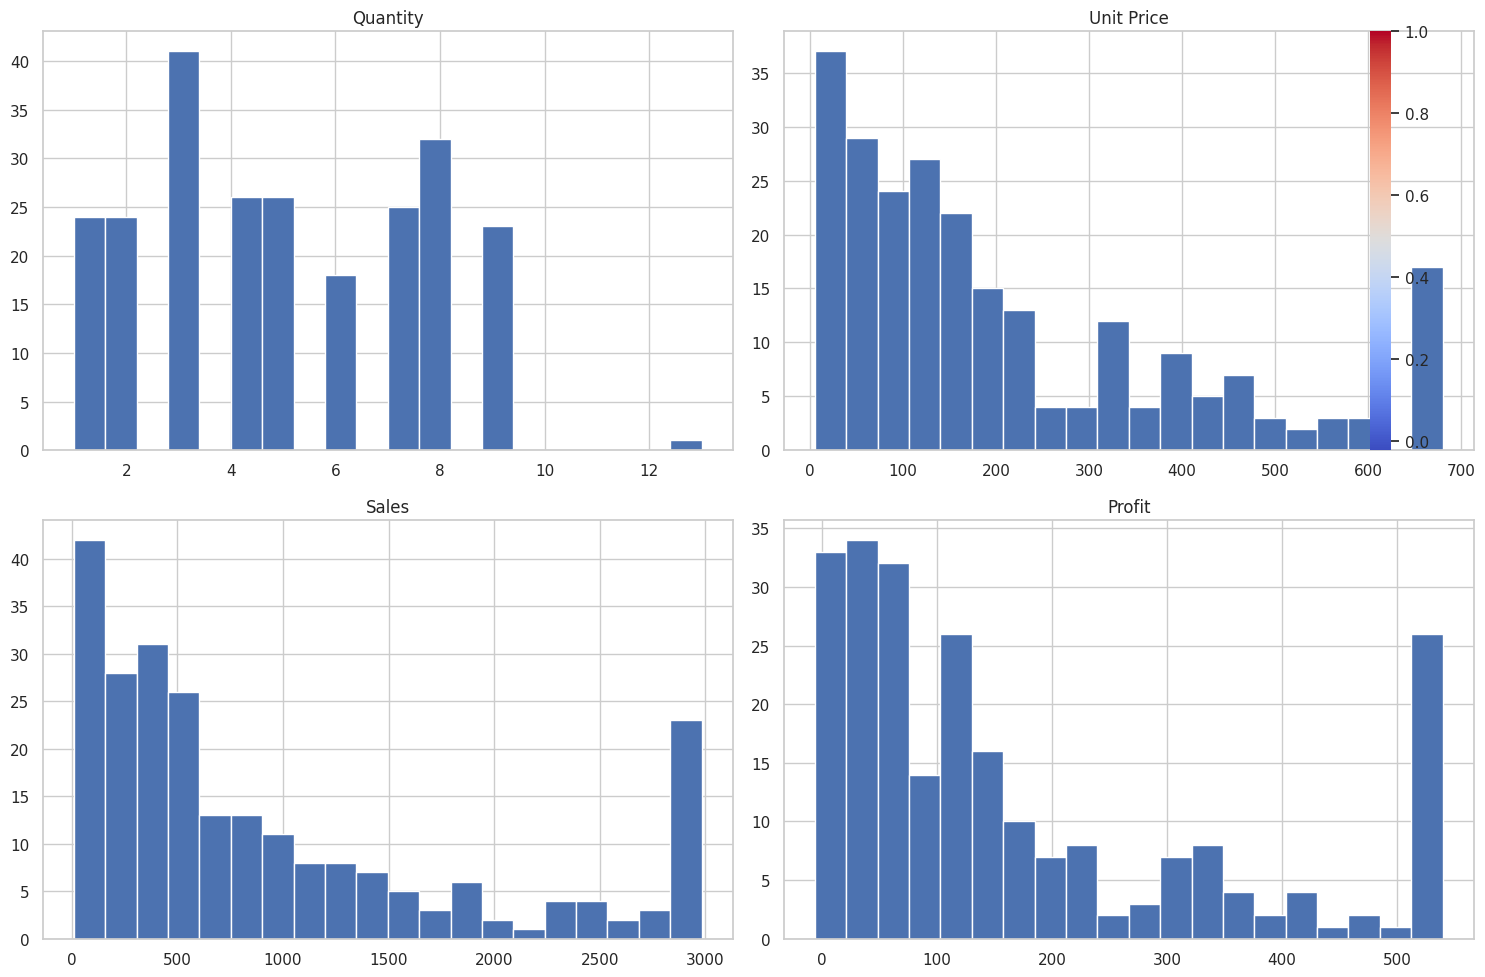

In [ ]:
# 5. Generate Dashboard Visualizations

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Histograms for numerical columns
df[num_cols].hist(ax=axes[0, 0], bins=20)
axes[0, 0].set_title("Distribution of Numerical Features")

# Plot 2: Correlation Heatmap
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", ax=axes[0, 1])
axes[0, 1].set_title("Correlation Heatmap")

# Plot 3: Boxplot for numerical columns
sns.boxplot(data=df[num_cols], ax=axes[1, 0])
axes[1, 0].set_title("Boxplot of Numerical Features")
axes[1, 0].tick_params(axis="x", rotation=45)

# Plot 4: Categorical distribution
if len(cat_cols) > 0:
    first_cat = cat_cols[0]
    sns.countplot(data=df, x=first_cat, ax=axes[1, 1])
    axes[1, 1].set_title(f"Distribution of {first_cat}")
    axes[1, 1].tick_params(axis="x", rotation=45)
else:
    axes[1, 1].text(
        0.5, 0.5,
        "No categorical columns available",
        ha="center",
        va="center"
    )
    axes[1, 1].set_title("Categorical Distribution")

plt.tight_layout()
plt.show()

In [ ]:
# 6. Save cleaned dataset

output_file = "cleaned_dataset.csv"
df.to_csv(output_file, index=False)

print("Cleaned dataset saved successfully!")

# Download the cleaned CSV
from google.colab import files
files.download(output_file)

Cleaned dataset saved successfully!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
print("Final Dataset Shape:", df.shape)

print("\nFirst 5 rows:")
display(df.head())

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Final Dataset Shape: (240, 10)

First 5 rows:


,Order ID,Order Date,Customer,Region,Category,Product,Quantity,Unit Price,Sales,Profit
0,ORD-0001,2025-06-10,Customer 041,North,Electronics,Tablet,6,680.0575,2983.12875,539.44
1,ORD-0002,2025-05-16,Customer 071,North,Accessories,Mouse,5,88.1600,440.80000,58.99
2,ORD-0003,2025-08-19,Customer 029,South,Accessories,USB Hub,3,162.3600,487.08000,111.28
3,ORD-0004,2025-02-26,Customer 063,North,Furniture,Chair,5,387.7000,1938.50000,304.86
4,ORD-0005,2025-06-23,Customer 061,West,Furniture,Chair,7,354.7200,2483.04000,539.44



Missing values:
Order ID      0
Order Date    0
Customer      0
Region        0
Category      0
Product       0
Quantity      0
Unit Price    0
Sales         0
Profit        0
dtype: int64

Duplicate rows: 0


In [ ]:
print("Final Dataset Shape:", df.shape)

print("\nFirst 5 rows:")
display(df.head())

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Final Dataset Shape: (240, 10)

First 5 rows:


,Order ID,Order Date,Customer,Region,Category,Product,Quantity,Unit Price,Sales,Profit
0,ORD-0001,2025-06-10,Customer 041,North,Electronics,Tablet,6,680.0575,2983.12875,539.44
1,ORD-0002,2025-05-16,Customer 071,North,Accessories,Mouse,5,88.1600,440.80000,58.99
2,ORD-0003,2025-08-19,Customer 029,South,Accessories,USB Hub,3,162.3600,487.08000,111.28
3,ORD-0004,2025-02-26,Customer 063,North,Furniture,Chair,5,387.7000,1938.50000,304.86
4,ORD-0005,2025-06-23,Customer 061,West,Furniture,Chair,7,354.7200,2483.04000,539.44



Missing values:
Order ID      0
Order Date    0
Customer      0
Region        0
Category      0
Product       0
Quantity      0
Unit Price    0
Sales         0
Profit        0
dtype: int64

Duplicate rows: 0


In [ ]:
import pandas as pd

# Ensure 'Order Date' is datetime
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')

# Find the most recent date in the dataset
latest_date = df['Order Date'].max()

if pd.notnull(latest_date):
    # Filter for the last 1 month of data relative to the latest date in the set
    start_date = latest_date - pd.DateOffset(months=1)
    df_filtered = df[df['Order Date'] >= start_date]

    print(f"Latest date in dataset: {latest_date.date()}")
    print(f"Filtering from: {start_date.date()}")
    print(f"Filtered results ({len(df_filtered)} rows):")
    display(df_filtered.head())
else:
    print("Error: No valid dates found in 'Order Date' column.")

Latest date in dataset: 2025-12-31
Filtering from: 2025-11-30
Filtered results (20 rows):


,Order ID,Order Date,Customer,Region,Category,Product,Quantity,Unit Price,Sales,Profit
15,ORD-0016,2025-12-16,Customer 013,East,Furniture,Chair,2,404.40,808.80,148.23
21,ORD-0022,2025-12-08,Customer 057,West,Furniture,Desk,1,114.01,114.01,27.82
67,ORD-0068,2025-12-18,Customer 076,East,Office Supplies,Printer Paper,3,13.56,40.68,-1.54
68,ORD-0069,2025-12-26,Customer 041,West,Furniture,Cabinet,1,382.85,382.85,27.30
69,ORD-0070,2025-12-26,Customer 043,West,Accessories,Mouse,8,145.96,1167.68,106.94
